In [1]:
import torch.nn as nn
import torch.nn.functional as F
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from typing import Tuple, Optional

In [2]:
class MultiPSF(nn.Module):
    """
    - Candidate spot locations are fixed (offsets).
    - Learn which candidates are "on" via gates in [0,1].
    - All active spots have equal amplification because we normalize gates to sum to 1.
    - Also learns a single shared sigma (spot width).
    """
    def __init__(self, K, offsets, sigma_init=0.0, gate_init=0.0, device="cpu"):
        super().__init__()
        # assert K % 2 == 1
        self.K = K
        self.device = device

        # (S,2) candidate offsets (dx, dy)
        self.register_buffer("offsets", torch.tensor(offsets, dtype=torch.float32, device=device))

        # learnable scalar spot width
        self.log_sigma = nn.Parameter(torch.tensor(float(sigma_init), device=device))

        # learnable gate logits for each candidate spot (S,)
        # sigmoid(logits) -> gate in (0,1)
        S = len(offsets)
        self.gate_logits = nn.Parameter(torch.full((S,), float(gate_init), device=device))

    def forward(self, eps=1e-12):
        K = self.K
        c = K // 2

        sigma = F.softplus(self.log_sigma) + 1e-8  # >0
        gates = torch.sigmoid(self.gate_logits)    # (S,) in (0,1)

        # normalize so total weight across spots sums to 1 (equal-ish among active)
        w = gates / (gates.sum() + eps)            # (S,)

        ax = torch.arange(K, device=self.offsets.device, dtype=torch.float32)
        yy, xx = torch.meshgrid(ax, ax, indexing="ij")  # (K,K)

        x0 = c + self.offsets[:, 0]  # (S,)
        y0 = c + self.offsets[:, 1]  # (S,)

        dx = xx[None, :, :] - x0[:, None, None]  # (S,K,K)
        dy = yy[None, :, :] - y0[:, None, None]  # (S,K,K)

        spots = torch.exp(-(dx*dx + dy*dy) / (2.0 * sigma * sigma))  # (S,K,K)

        psf = (w[:, None, None] * spots).sum(dim=0)  # (K,K), nonnegative
        psf = psf / (psf.sum() + eps)                # sum=1
        return psf

    def effective_num_spots(self):
        # continuous proxy for "how many are on"
        return torch.sigmoid(self.gate_logits).sum()


In [12]:
class RMLPSFLayer(nn.Module):
    """
    A layer that models the Random Multi-Focal Lenslet Point Spread Function using Gaussians.
    Converted from JAX/Equinox to PyTorch.
    """
    def __init__(
        self,
        object_size: int,
        num_gaussians: int,
        psf_size: Tuple[int, int] = (32, 32),
        measurement_bias: float = 0.0,
        key: Optional[int] = None,  # used as random seed TODO: SEED EVERYTHING PROPERLY?
    ):
        super().__init__()
        assert psf_size[0] == psf_size[1], "PSF size must be square."

        self.num_gaussians = num_gaussians
        self.object_size = object_size
        self.psf_shape = psf_size
        self.measurement_bias = measurement_bias
        self.obj_padding = (0, 0)
        self.psf_padding = (0, 0)

        seed = key if key is not None else 0
        g = torch.Generator()
        g.manual_seed(seed)

        # --- Initialize means on a grid with small perturbations ---
        grid_size = math.ceil(math.sqrt(num_gaussians))
        x = torch.linspace(-psf_size[1] / 2 * 0.7, psf_size[1] / 2 * 0.7, grid_size)
        y = torch.linspace(-psf_size[0] / 2 * 0.7, psf_size[0] / 2 * 0.7, grid_size)
        Y, X = torch.meshgrid(y, x, indexing="ij")
        grid_means = torch.stack([Y.flatten(), X.flatten()], dim=1)[:num_gaussians]
        perturbation = torch.randn(num_gaussians, 2, generator=g) * (psf_size[0] / grid_size / 4)
        self.means = nn.Parameter(grid_means + perturbation)

        # --- Initialize covariances as scaled identity matrices ---
        single_scale = torch.empty(num_gaussians).uniform_(1, 5)
        covs = torch.stack([torch.eye(2) * s for s in single_scale])  # (N, 2, 2)
        self.covs = nn.Parameter(covs)

        # --- Initialize weights uniformly ---
        self.weights = nn.Parameter(torch.ones(num_gaussians) / num_gaussians)

        # --- Cached coordinate grid (not a parameter) ---
        y_lin = torch.linspace(-psf_size[0] // 2, psf_size[0] // 2, psf_size[0])
        x_lin = torch.linspace(-psf_size[1] // 2, psf_size[1] // 2, psf_size[1])
        Y_grid, X_grid = torch.meshgrid(y_lin, x_lin, indexing="ij")
        grid = torch.stack([Y_grid.flatten(), X_grid.flatten()], dim=1)  # (H*W, 2)
        self.register_buffer("grid", grid)

    def compute_psf(self) -> torch.Tensor:
        """
        Compute the PSF from the current parameters.
        Normalizes total energy to 1.
        Returns: (H, W) tensor
        """
        # (1, H*W, 2) - (N, 1, 2) => (N, H*W, 2)
        centered = self.grid[None, :, :] - self.means[:, None, :]

        # Quadratic form: centered @ cov_inv @ centered^T
        covs_inv = torch.linalg.inv(self.covs)  # (N, 2, 2)
        quad_form = torch.einsum("npi,nij,npj->np", centered, covs_inv, centered)
        quad_form = quad_form.clamp(-100, 100)

        # Gaussian values
        gaussians = torch.exp(-0.5 * quad_form)  # (N, H*W)

        # Normalize each Gaussian individually
        gaussians = gaussians / (gaussians.sum(dim=1, keepdim=True) + 1e-10)

        # Weight and sum
        weighted_sum = (self.weights[:, None] * gaussians).sum(dim=0)  # (H*W,)

        psf = weighted_sum.reshape(self.psf_shape)
        return psf / (psf.sum() + 1e-10)

    def normalize_psf(self) -> "RMLPSFLayer":
        """
        Projects parameters to valid ranges:
        - covariances: symmetric, positive definite, min eigenvalue >= 1
        - weights: non-negative, sum to 1
        - means: clipped to PSF bounds
        Uses in-place update (no gradient tracking). Call after each optimizer step.
        """
        with torch.no_grad():
            # Symmetrize and enforce positive definiteness
            sym_covs = (self.covs + self.covs.transpose(-2, -1)) / 2
            eigvals, eigvecs = torch.linalg.eigh(sym_covs)
            eigvals = eigvals.clamp(min=1.0)  # min std=1 prevents streaking
            new_covs = torch.einsum("nij,nj,nkj->nik", eigvecs, eigvals, eigvecs)
            self.covs.copy_(new_covs)

            # Normalize weights
            w = self.weights.clamp(min=0)
            self.weights.copy_(w / (w.sum() + 1e-10))

            # Clip means to PSF bounds
            bound = self.psf_shape[0] // 2 * 0.8
            self.means.copy_(self.means.clamp(-bound, bound))

        return self

In [4]:
class Convolve2d(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.K = K

    def forward(self, x, psf):
        """
        x:   (B,1,H,W)
        psf: (K,K)  or (1,1,K,K)
        returns y: (B,1,H,W)
        """
        # ensure psf is (1,1,K,K)
        if psf.ndim == 2:
            psf = psf[None, None, :, :]
        elif psf.ndim != 4:
            raise ValueError(f"psf must be (K,K) or (1,1,K,K); got {psf.shape}")

        K_h, K_w = psf.shape[-2], psf.shape[-1]

        # flip for true convolution (conv2d is correlation by default)
        psf_conv = torch.flip(psf, dims=(-2, -1))

        # asymmetric padding to handle even or odd kernels correctly
        pad_top    = (K_h - 1) // 2
        pad_bottom = K_h // 2
        pad_left   = (K_w - 1) // 2
        pad_right  = K_w // 2

        x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom))
        return F.conv2d(x, psf_conv, padding=0)

        # return F.conv2d(x, psf_conv, padding=(pad_h, pad_w))

In [5]:
class ConvolveFF(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.K = K

    def forward(self, x, psf):
        """
        x:   (B,1,H,W)
        psf: (K,K)  or (1,1,K,K)
        returns y: (B,1,H,W)
        """
        B, C, H, W = x.shape
        
        # ensure psf is (1,1,K,K)
        if psf.ndim == 2:
            psf = psf[None, None, :, :]
        elif psf.ndim != 4:
            raise ValueError(f"psf must be (K,K) or (1,1,K,K); got {psf.shape}")

        K = psf.shape[-1]
        if K != self.K:
            raise ValueError(f"Expected PSF kernel size {self.K}, got {K}")

        # Pad PSF to image size and center it
        psf_pad = torch.zeros((1, 1, H, W), device=psf.device, dtype=psf.dtype)
        pad_h = (H - K) // 2
        pad_w = (W - K) // 2
        psf_pad[..., pad_h:pad_h+K, pad_w:pad_w+K] = psf
        # psf_pad = psf
        
        # Shift PSF so center is at (0,0) for FFT
        psf_pad = torch.fft.ifftshift(psf_pad, dim=(-2, -1))
        
        # FFT convolution
        X = torch.fft.fft2(x)
        H_fft = torch.fft.fft2(psf_pad)
        Y = X * H_fft
        
        return torch.fft.ifft2(Y).real, psf_pad

In [14]:
class WienerDeconv(nn.Module):
    def __init__(self, lam_init=1e-3, device="cpu"):
        super().__init__()
        self.log_lambda = nn.Parameter(torch.tensor(float(lam_init), device=device).log())

    def forward(self, y, psf, eps=1e-8):
        # y: (B,1,H,W), psf
        lam = F.softplus(self.log_lambda) + eps
        if psf.ndim == 4:
            psf = psf.squeeze(0).squeeze(0)
        Hf = torch.fft.fft2(psf)[None, None, :, :]  # (1,1,H,W)
        Y = torch.fft.fft2(y)
        Xhat = torch.conj(Hf) * Y / (torch.abs(Hf) ** 2 + lam)
        x_hat = torch.fft.ifft2(Xhat).real
        return x_hat


In [7]:
class E2E(nn.Module):
    def __init__(self, psf_module, convolve_module, recon_module):
        super().__init__()
        self.psf_module = psf_module
        self.convolve_module = convolve_module
        self.recon_module = recon_module

    def forward(self, x):
        psf = self.psf_module.compute_psf()       # TODO: FIND OUTPUT SHAPE AND INPUT SHAPE OF EVERYTHING   
        y = self.convolve_module(x, psf)            # (B,1,H,W)
        x_hat = self.recon_module(y, psf)       # (B,1,H,W) #WHAT IS THE PSF SHAPE!!
        return x_hat, y, psf

In [24]:
def run_one_image_multipsf(
    x,
    steps=10000,
    lr=1e-2,
    K=32,
    convolve_class = Convolve2d,
    offsets=None,
    viz_every=1000,
    print_every=100,
):
    """
    x: torch tensor (1,1,H,W)
    offsets: list of (dx, dy) candidate spot offsets relative to center.
             Example offsets provided if None.
    """
    device = x.device
    B, C, H, W = x.shape

    # Default candidate spot locations (a small grid); adjust as you like
    if offsets is None:
        d = 6
        
        offsets = [(0, 0), ( d, 0), (-d, 0), (0, d), (0, -d), ( d, d), ( d,-d), (-d, d), (-d,-d)]

    print(offsets)
    # Modules
    object_size = 96 
    num_gaussian = 25 # TODO changing this
    psf_size = (32, 32) 
    seed_value = 42
    # key = np.random() # TODO CHANGE MY SEEDING!!
    
    psf_mod = RMLPSFLayer(object_size, num_gaussian, psf_size, key=seed_value).to(device)
    convolve_mod = convolve_class(K).to(device)
    recon_mod = WienerDeconv(lam_init=1e-3, device=device).to(device)

    model = E2E(psf_mod, convolve_mod, recon_mod).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for step in range(steps):
        x_hat, y, psf = model(x)
        loss = F.l1_loss(x_hat, x)

        opt.zero_grad()
        loss.backward()
        opt.step()
        model.psf_module.normalize_psf() 

        if step % print_every == 0 or step == steps-1:
            # MultiPSF-specific diagnostics
            # with torch.no_grad():
            #     sigma = F.softplus(model.psf_module.log_sigma).item()
            #     eff_spots = model.psf_module.effective_num_spots().item()
            #     gate_mean = torch.sigmoid(model.psf_module.gate_logits).mean().item()
            print(
                f"step {step:4d} | loss {loss.item():.6f} | "
                # f"sigma {sigma:.4f} | eff_spots {eff_spots:.2f} | gate_mean {gate_mean:.3f}"
            )

        if viz_every is not None and (step % viz_every == 0 or step == steps - 1):
            with torch.no_grad():
                fig, axs = plt.subplots(1, 4, figsize=(12, 3))
                axs[0].imshow(x[0, 0].detach().cpu(), cmap="gray");     axs[0].set_title("x (GT)")
                axs[1].imshow(y[0, 0].detach().cpu(), cmap="gray");     axs[1].set_title("y (meas)")
                axs[2].imshow(x_hat[0, 0].detach().cpu(), cmap="gray"); axs[2].set_title("x_hat")
                axs[3].imshow(psf.detach().cpu(), cmap="gray");         axs[3].set_title("PSF")
                for ax in axs: ax.axis("off")
                plt.show()

    return model

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Example numpy image
K = 32
image = np.zeros((K, K))
image[4:10, 4:10] = 1.0
image[10:22, 22:27] = 1.0
image[26:30, 6:24] = 1.0
image = image / np.sum(image)
image = image.astype(np.float32)

# Convert to torch tensor
x = torch.from_numpy(image).unsqueeze(0).unsqueeze(0).to(device)
print(x.shape)

torch.Size([1, 1, 32, 32])


In [10]:
def random_offsets_disk(num_spots: int, max_radius: int, include_center: bool = True, seed: int | None = None):
    """
    Returns a list of (dx, dy) integer offsets with unique locations, sampled inside a disk.
    max_radius is in pixels.
    """
    rng = random.Random(seed)
    offsets = set()

    if include_center:
        offsets.add((0, 0))

    # oversample then uniquify
    while len(offsets) < num_spots:
        # sample radius with sqrt for area-uniform
        r = max_radius * math.sqrt(rng.random())
        theta = 2 * math.pi * rng.random()
        dx = int(round(r * math.cos(theta)))
        dy = int(round(r * math.sin(theta)))
        if dx == 0 and dy == 0 and not include_center:
            continue
        offsets.add((dx, dy))

    return list(offsets)

[(0, 0), (6, 0), (-6, 0), (0, 6), (0, -6), (6, 6), (6, -6), (-6, 6), (-6, -6)]
step    0 | loss 0.002456 | 


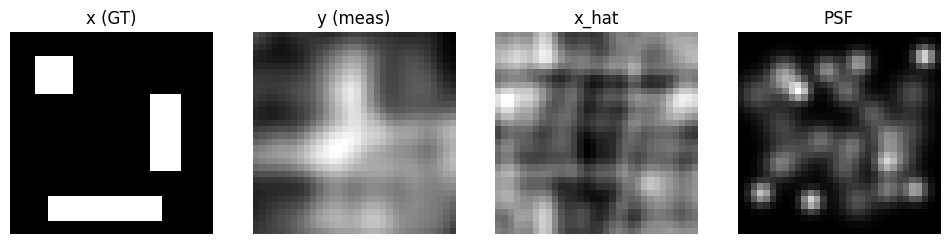

step  100 | loss 0.001367 | 
step  200 | loss 0.001263 | 
step  300 | loss 0.001174 | 
step  400 | loss 0.001132 | 
step  500 | loss 0.001131 | 
step  600 | loss 0.001105 | 
step  700 | loss 0.001097 | 
step  800 | loss 0.001087 | 
step  900 | loss 0.001086 | 
step 1000 | loss 0.001069 | 


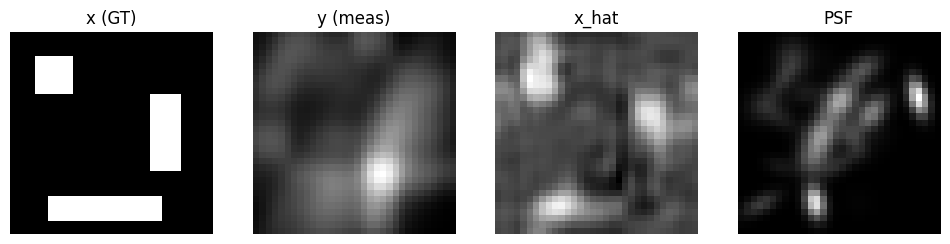

step 1100 | loss 0.001057 | 
step 1200 | loss 0.001053 | 
step 1300 | loss 0.001046 | 
step 1400 | loss 0.001027 | 
step 1500 | loss 0.001030 | 
step 1600 | loss 0.001012 | 
step 1700 | loss 0.001003 | 
step 1800 | loss 0.000998 | 
step 1900 | loss 0.000995 | 
step 2000 | loss 0.000983 | 


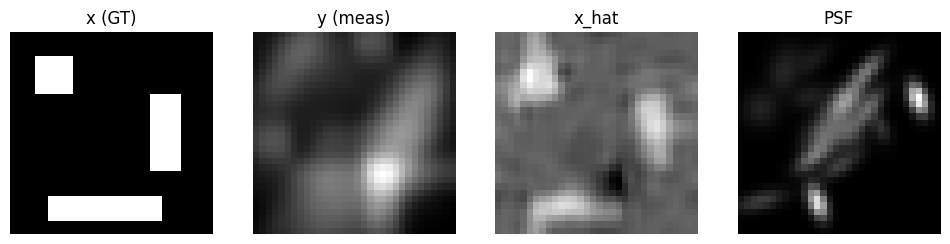

step 2100 | loss 0.000979 | 
step 2200 | loss 0.000982 | 
step 2300 | loss 0.000981 | 
step 2400 | loss 0.000977 | 
step 2500 | loss 0.000981 | 
step 2600 | loss 0.000971 | 
step 2700 | loss 0.000977 | 
step 2800 | loss 0.000978 | 
step 2900 | loss 0.000970 | 
step 3000 | loss 0.000975 | 


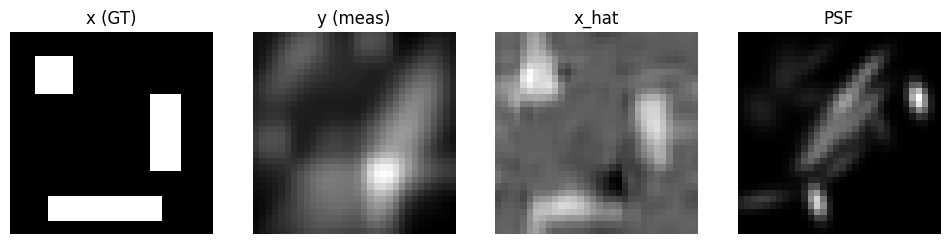

step 3100 | loss 0.000964 | 
step 3200 | loss 0.000986 | 
step 3300 | loss 0.000973 | 
step 3400 | loss 0.000965 | 
step 3500 | loss 0.000981 | 
step 3600 | loss 0.000968 | 
step 3700 | loss 0.000973 | 
step 3800 | loss 0.000973 | 
step 3900 | loss 0.000965 | 
step 4000 | loss 0.000968 | 


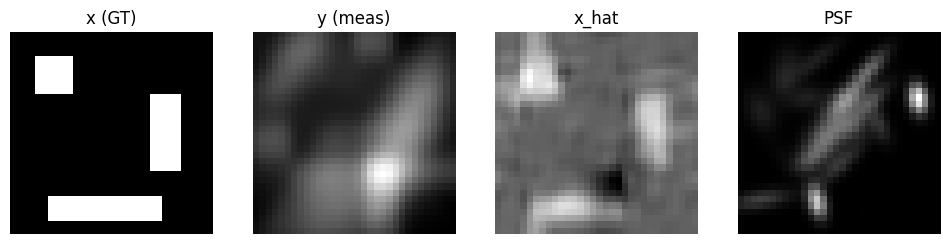

step 4100 | loss 0.000960 | 
step 4200 | loss 0.000968 | 
step 4300 | loss 0.000982 | 
step 4400 | loss 0.000979 | 
step 4500 | loss 0.000962 | 
step 4600 | loss 0.000967 | 
step 4700 | loss 0.000982 | 
step 4800 | loss 0.000972 | 
step 4900 | loss 0.000958 | 
step 5000 | loss 0.000970 | 


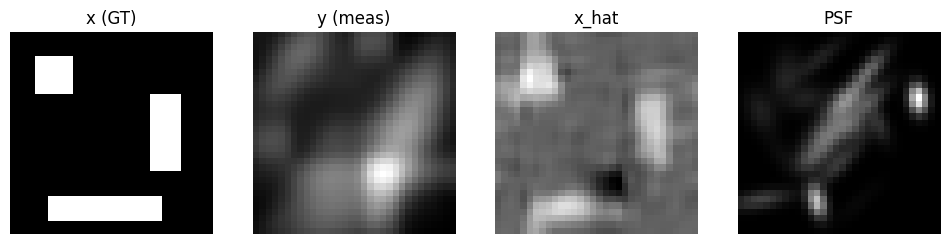

step 5100 | loss 0.000962 | 
step 5200 | loss 0.000961 | 
step 5300 | loss 0.000967 | 
step 5400 | loss 0.000961 | 
step 5500 | loss 0.000979 | 
step 5600 | loss 0.000967 | 
step 5700 | loss 0.000978 | 
step 5800 | loss 0.000970 | 
step 5900 | loss 0.000967 | 
step 6000 | loss 0.000957 | 


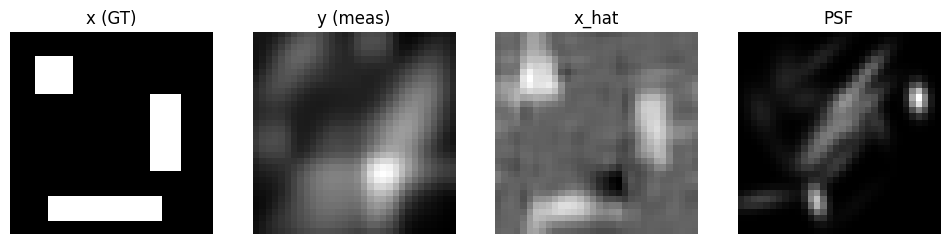

step 6100 | loss 0.000963 | 
step 6200 | loss 0.000964 | 
step 6300 | loss 0.000961 | 
step 6400 | loss 0.000959 | 
step 6500 | loss 0.000960 | 
step 6600 | loss 0.000956 | 
step 6700 | loss 0.000969 | 
step 6800 | loss 0.000969 | 
step 6900 | loss 0.000960 | 
step 7000 | loss 0.000965 | 


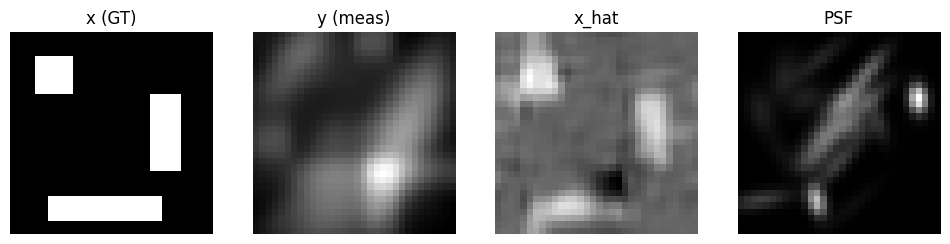

step 7100 | loss 0.000966 | 
step 7200 | loss 0.000960 | 
step 7300 | loss 0.000968 | 
step 7400 | loss 0.000959 | 
step 7500 | loss 0.000964 | 
step 7600 | loss 0.000963 | 
step 7700 | loss 0.000957 | 
step 7800 | loss 0.000967 | 
step 7900 | loss 0.000968 | 
step 8000 | loss 0.000957 | 


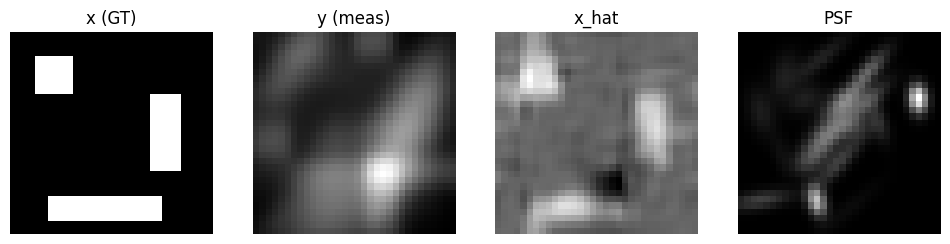

step 8100 | loss 0.000971 | 
step 8200 | loss 0.000981 | 
step 8300 | loss 0.000964 | 
step 8400 | loss 0.000956 | 
step 8500 | loss 0.000962 | 
step 8600 | loss 0.000956 | 
step 8700 | loss 0.000957 | 
step 8800 | loss 0.000972 | 
step 8900 | loss 0.000963 | 
step 9000 | loss 0.000969 | 


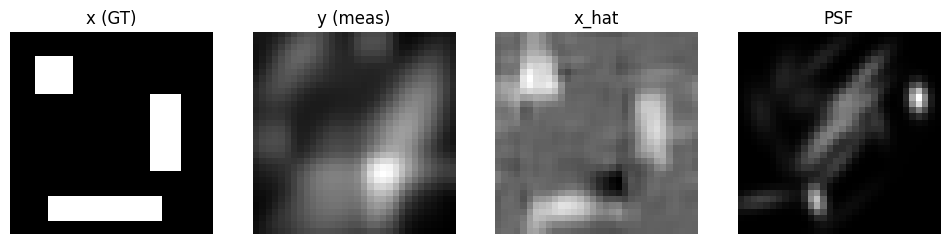

step 9100 | loss 0.000986 | 
step 9200 | loss 0.000954 | 
step 9300 | loss 0.000984 | 
step 9400 | loss 0.000970 | 
step 9500 | loss 0.000964 | 
step 9600 | loss 0.000971 | 
step 9700 | loss 0.000954 | 
step 9800 | loss 0.000979 | 
step 9900 | loss 0.000956 | 
step 9999 | loss 0.000981 | 


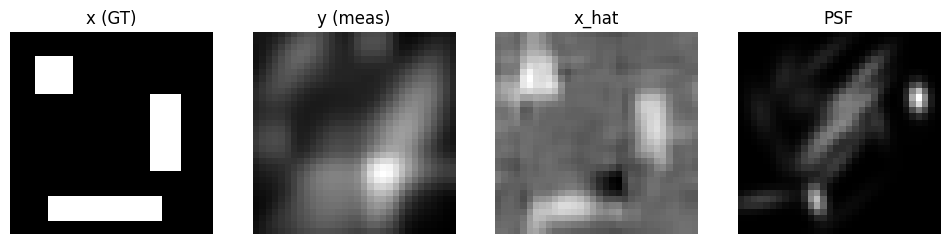

In [25]:

# offsets = random_offsets_disk(num_spots=5, max_radius=K//2 - 1, include_center=True)
model = run_one_image_multipsf(x, convolve_class = Convolve2d, K = K)

torch.Size([32, 32])


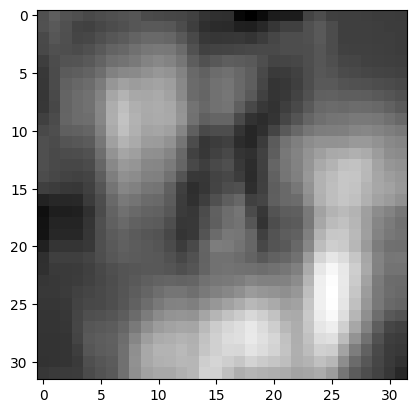

In [23]:
model.eval()

with torch.no_grad():
    psf = model.psf_module.compute_psf()   # (K, K)

psf_np = psf.detach().cpu().numpy()
print(psf.shape)

from scipy.signal import convolve2d, fftconvolve
result = fftconvolve(psf_np, image,mode='same')
plt.imshow(result,cmap='gray')
plt.show()